In [ ]:
from google.colab import files
uploaded = files.upload()

Saving churn.csv to churn.csv


Importing libs and dataset

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('/content/churn.csv')
df.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


Converting Churn from True/False into 1/0. Removing not relevant columns

In [ ]:
df['Churn'] = df['Churn?'].apply(lambda x: 1 if x.strip() == 'True.' else 0)

df.drop(['State', 'Phone', 'Churn?'], axis=1, inplace=True)

In [ ]:
df["Int'l Plan"] = df["Int'l Plan"].map({'yes': 1, 'no': 0})
df["VMail Plan"] = df["VMail Plan"].map({'yes': 1, 'no': 0})

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

Getting train/test values and scaling them. Training Logistic Regression model. Testing model

In [ ]:
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.98      0.92       566
           1       0.60      0.18      0.27       101

    accuracy                           0.86       667
   macro avg       0.73      0.58      0.60       667
weighted avg       0.83      0.86      0.82       667



In next codes we will be predicting churned customers and calculating percentage of churned customers to sample amount.
Sample customers will be 10%, 30%, 50%, 90% random customers and 100% customers in dataset

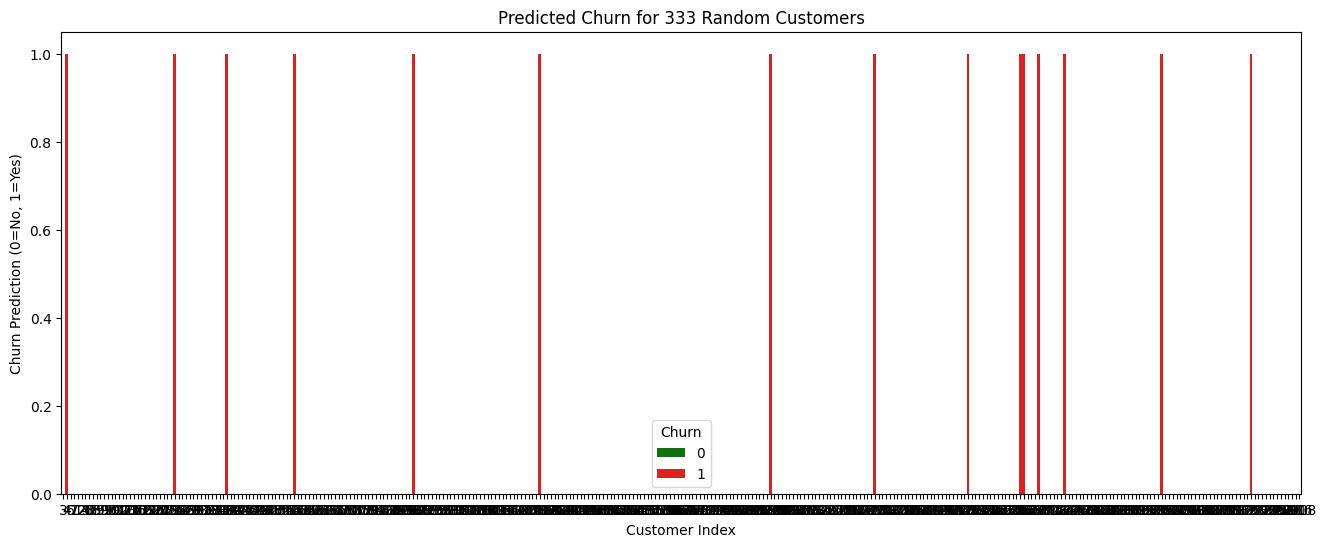

Number of predicted churned customers from 10% of dataset: 15
That mean's that percent of churn customers from random 10% of dataset equals: 4.50%


In [ ]:
sample = df.sample(n=333, random_state=1)
sample_X = sample.drop('Churn', axis=1)
sample_y = sample['Churn']

sample_X_scaled = scaler.transform(sample_X)

predictions = model.predict(sample_X_scaled)

results_df = sample.copy()
results_df['Predicted_Churn'] = predictions

plt.figure(figsize=(16, 6))
sns.barplot(
    x=results_df.index,
    y=results_df['Predicted_Churn'],
    hue=results_df['Predicted_Churn'],
    palette={0: 'green', 1: 'red'}
)
plt.title("Predicted Churn for 333 Random Customers")
plt.xlabel("Customer Index")
plt.ylabel("Churn Prediction (0=No, 1=Yes)")
plt.legend(title='Churn')
plt.show()

churn_count = (results_df['Predicted_Churn'] == 1).sum()
print(f"Number of predicted churned customers from 10% of dataset: {churn_count}")
print(f"That mean's that percent of churn customers from random 10% of dataset equals: {churn_count / 333:.2%}")

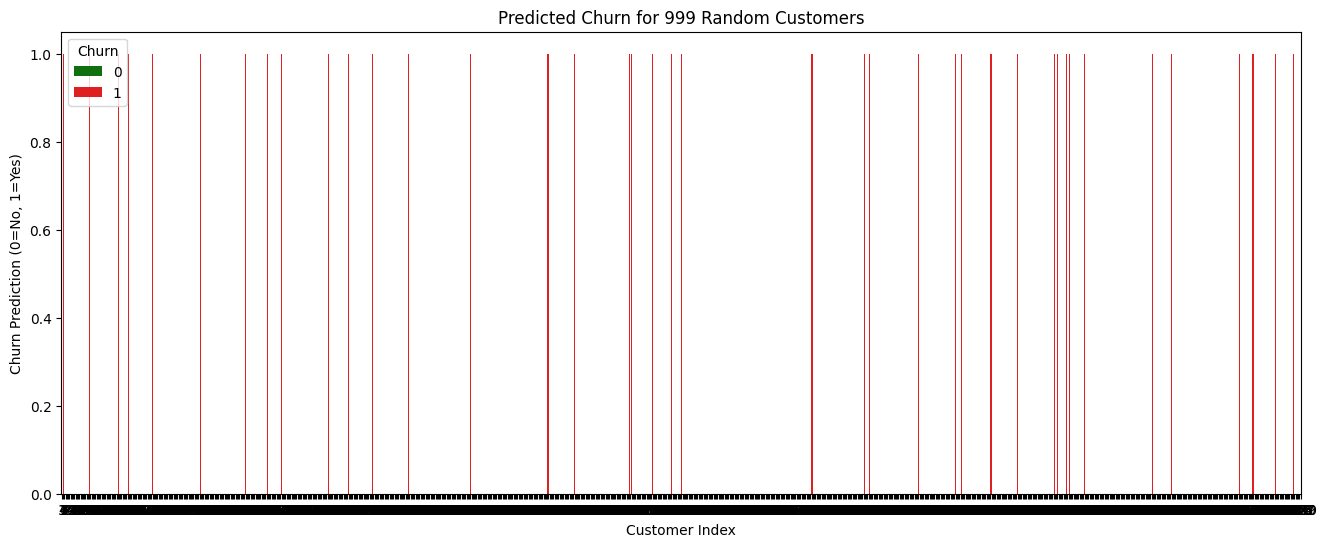

Number of predicted churned customers from 30% of dataset: 45
That mean's that percent of churn customers from random 30% of dataset equals: 4.50%


In [ ]:
sample = df.sample(n=999, random_state=1)
sample_X = sample.drop('Churn', axis=1)
sample_y = sample['Churn']

sample_X_scaled = scaler.transform(sample_X)

predictions = model.predict(sample_X_scaled)

results_df = sample.copy()
results_df['Predicted_Churn'] = predictions

plt.figure(figsize=(16, 6))
sns.barplot(
    x=results_df.index,
    y=results_df['Predicted_Churn'],
    hue=results_df['Predicted_Churn'],
    palette={0: 'green', 1: 'red'}
)
plt.title("Predicted Churn for 999 Random Customers")
plt.xlabel("Customer Index")
plt.ylabel("Churn Prediction (0=No, 1=Yes)")
plt.legend(title='Churn')
plt.show()

churn_count = (results_df['Predicted_Churn'] == 1).sum()
print(f"Number of predicted churned customers from 30% of dataset: {churn_count}")
print(f"That mean's that percent of churn customers from random 30% of dataset equals: {churn_count / 999:.2%}")

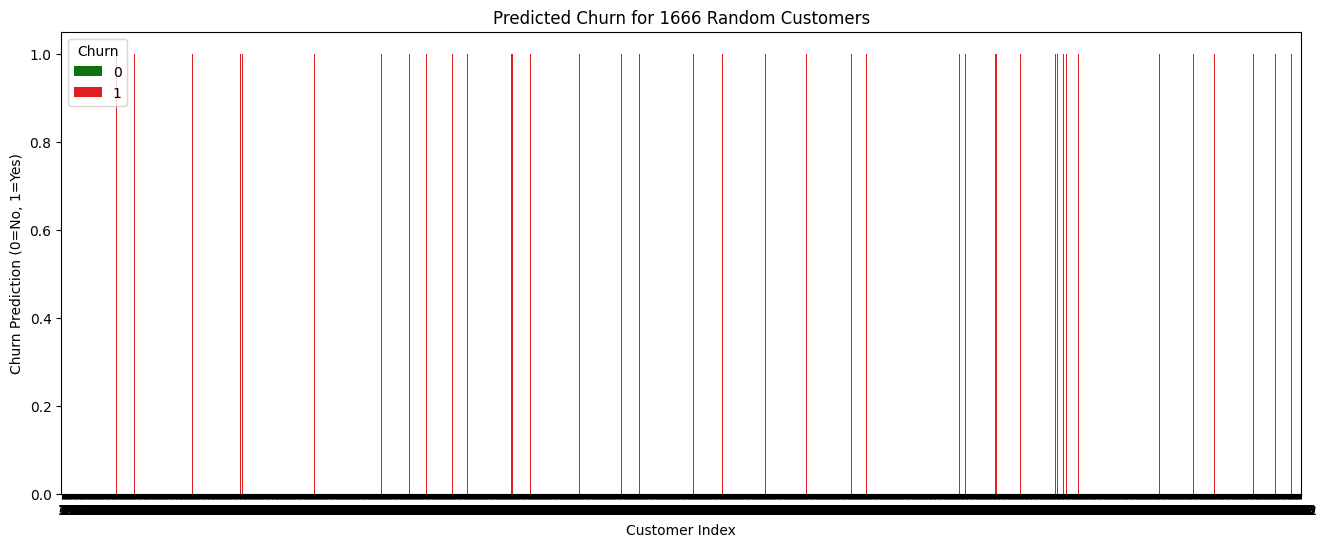

Number of predicted churned customers from 50% of dataset: 69
That mean's that percent of churn customers from random 50% of dataset equals: 4.14%


In [ ]:
fifty_percent = int(len(df) / 2)
sample = df.sample(n=fifty_percent, random_state=1)
sample_X = sample.drop('Churn', axis=1)
sample_y = sample['Churn']

sample_X_scaled = scaler.transform(sample_X)

predictions = model.predict(sample_X_scaled)

results_df = sample.copy()
results_df['Predicted_Churn'] = predictions

plt.figure(figsize=(16, 6))
sns.barplot(
    x=results_df.index,
    y=results_df['Predicted_Churn'],
    hue=results_df['Predicted_Churn'],
    palette={0: 'green', 1: 'red'}
)
plt.title(f"Predicted Churn for {fifty_percent} Random Customers")
plt.xlabel("Customer Index")
plt.ylabel("Churn Prediction (0=No, 1=Yes)")
plt.legend(title='Churn')
plt.show()

churn_count = (results_df['Predicted_Churn'] == 1).sum()
print(f"Number of predicted churned customers from 50% of dataset: {churn_count}")
print(f"That mean's that percent of churn customers from random 50% of dataset equals: {churn_count / fifty_percent:.2%}")

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


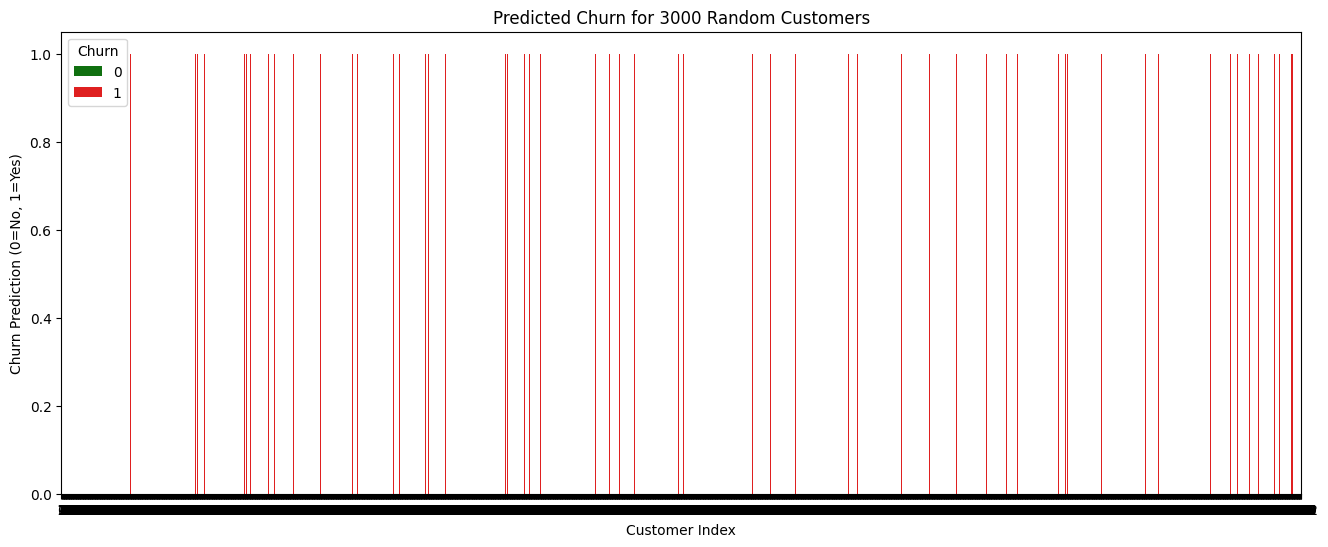

Number of predicted churned customers from 90% of dataset: 151
That mean's that percent of churn customers from random 90% of dataset equals: 5.03%


In [ ]:
sample = df.sample(n=3000, random_state=1)
sample_X = sample.drop('Churn', axis=1)
sample_y = sample['Churn']

sample_X_scaled = scaler.transform(sample_X)

predictions = model.predict(sample_X_scaled)

results_df = sample.copy()
results_df['Predicted_Churn'] = predictions

plt.figure(figsize=(16, 6))
sns.barplot(
    x=results_df.index,
    y=results_df['Predicted_Churn'],
    hue=results_df['Predicted_Churn'],
    palette={0: 'green', 1: 'red'}
)
plt.title(f"Predicted Churn for 3000 Random Customers")
plt.xlabel("Customer Index")
plt.ylabel("Churn Prediction (0=No, 1=Yes)")
plt.legend(title='Churn')
plt.show()

churn_count = (results_df['Predicted_Churn'] == 1).sum()
print(f"Number of predicted churned customers from 90% of dataset: {churn_count}")
print(f"That mean's that percent of churn customers from random 90% of dataset equals: {churn_count / 3000:.2%}")

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


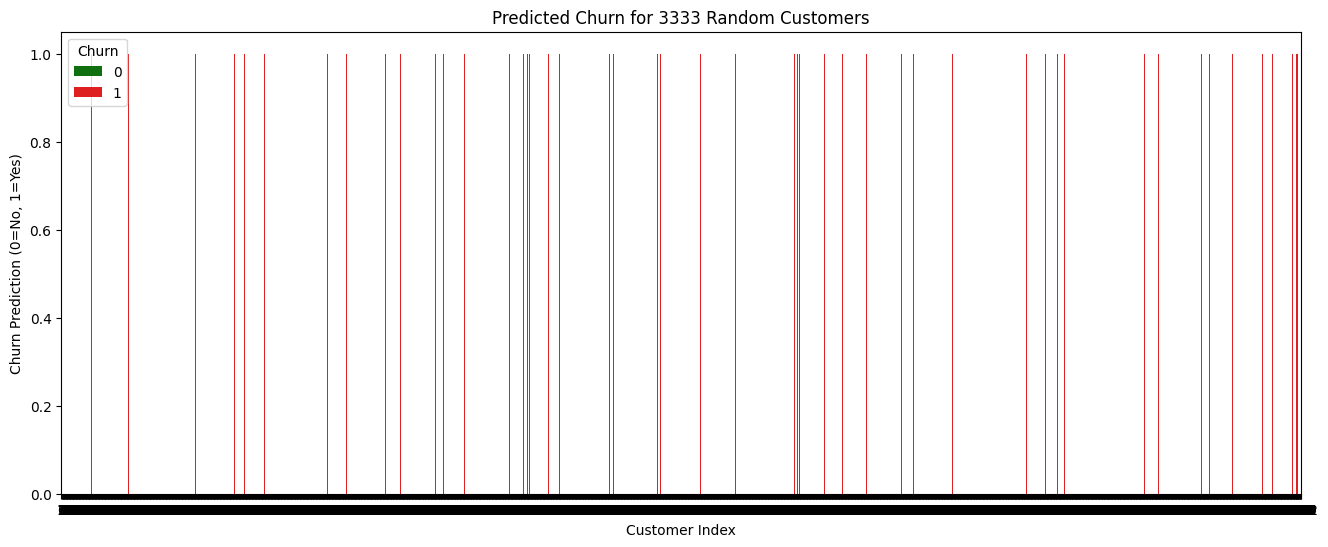

Number of predicted churned customers from 100% of dataset: 169
That mean's that percent of churn customers from random 100% of dataset equals: 5.07%


In [ ]:
total_amount = len(df)
sample = df.sample(n=total_amount)
sample_X = sample.drop('Churn', axis=1)
sample_y = sample['Churn']

sample_X_scaled = scaler.transform(sample_X)

predictions = model.predict(sample_X_scaled)

results_df = sample.copy()
results_df['Predicted_Churn'] = predictions

plt.figure(figsize=(16, 6))
sns.barplot(
    x=results_df.index,
    y=results_df['Predicted_Churn'],
    hue=results_df['Predicted_Churn'],
    palette={0: 'green', 1: 'red'}
)
plt.title(f"Predicted Churn for {total_amount} Random Customers")
plt.xlabel("Customer Index")
plt.ylabel("Churn Prediction (0=No, 1=Yes)")
plt.legend(title='Churn')
plt.show()

churn_count = (results_df['Predicted_Churn'] == 1).sum()
print(f"Number of predicted churned customers from 100% of dataset: {churn_count}")
print(f"That mean's that percent of churn customers from random 100% of dataset equals: {churn_count / total_amount:.2%}")

Conclusion: Here we can see depency of percentage of random used data and predicted results.\
From 100% of customers we have 5.07% of customers churned\
From random 90% of customers 5.03%\
From random 50% of customers 4.14%\
From random 30% of customers 4.50%\
From random 10% of customers 4.50%